# Random Forest sobre `data_model_borda30`

En esta notebook cargamos el dataset `data_model_borda30`, hacemos una división de datos segura para evitar fuga de datos, optimizamos los hiperparámetros de un modelo Random Forest y evaluamos el modelo usando **Weighted F1 Score** y **AUC-ROC**.

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import hashlib
import json
import datetime
import random
import subprocess

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score, confusion_matrix
from pytorch_tabnet.tab_model import TabNetClassifier

# Reproducibility seed
random_state = 42
random.seed(random_state)
np.random.seed(random_state)
try:
    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)
    # enable deterministic algorithms if supported
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass
except Exception:
    pass

# Workspace and dataset
workspace_dir = r'c:\Users\ricar\OneDrive\Desktop\TESIS'
file_path = os.path.join(workspace_dir, 'data_model_borda30.csv')

if not os.path.exists(file_path):
    raise FileNotFoundError(f'No se encontró el archivo: {file_path}')

print('Cargando dataset:', file_path)
data = pd.read_csv(file_path)
print('Shape:', data.shape)
print(data.head())
print('\nColumnas:', data.columns.tolist())
print('\nTipo de label:', data['Type'].dtype)

print('\nDistribución de clases:')
print(data['Type'].value_counts())

# Create timestamped results directory structure for reproducibility
timestamp = datetime.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')
results_root = os.path.join(workspace_dir, 'results', timestamp)
results_models_dir = os.path.join(results_root, 'models')
results_metrics_dir = os.path.join(results_root, 'metrics')
results_logs_dir = os.path.join(results_root, 'logs')
results_figures_dir = os.path.join(results_root, 'figures')
results_reports_dir = os.path.join(results_root, 'reports')
for d in [results_root, results_models_dir, results_metrics_dir, results_logs_dir, results_figures_dir, results_reports_dir]:
    os.makedirs(d, exist_ok=True)

# Dataset hash for manifest
def file_hash(path, algo='sha256'):
    h = hashlib.new(algo)
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

dataset_hash = file_hash(file_path)
print('Dataset hash (sha256):', dataset_hash)

# Git commit (best-effort)
git_commit = None
try:
    git_commit = subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=workspace_dir, text=True).strip()
    print('Git commit:', git_commit)
except Exception:
    print('No se detectó git o hubo un error obteniendo el commit.')

# Save a minimal manifest
manifest = {
    'timestamp_utc': timestamp,
    'dataset': os.path.basename(file_path),
    'dataset_hash_sha256': dataset_hash,
    'git_commit': git_commit,
    'random_state': random_state,
}
with open(os.path.join(results_root, 'manifest.json'), 'w', encoding='utf-8') as mf:
    json.dump(manifest, mf, indent=2)

# Save current pip freeze to requirements file (best-effort)
try:
    reqs = subprocess.check_output(['pip', 'freeze'], text=True)
    with open(os.path.join(results_root, 'requirements.txt'), 'w', encoding='utf-8') as rf:
        rf.write(reqs)
except Exception:
    pass


Cargando dataset: c:\Users\ricar\OneDrive\Desktop\TESIS\data_model_borda30.csv
Shape: (23779, 31)
   w_t_PEC_A6  w_t_rms_D3  w_f_maxval_D3  w_f_mean_A6      f_std  \
0   12.329105    0.138755     -14.651670   -59.838367  14.393881   
1    3.662787    0.168017     -13.608228   -75.286007  14.257243   
2   21.300689    0.151864     -14.707321   -67.184415  16.163072   
3    3.611111    0.129489     -16.798640   -76.962843  14.356738   
4   17.168839    0.159266     -14.708640   -66.610681  17.097193   

   w_t_peak2peak_D3  t_peak2rms      f_rms     t_rms  w_t_PEC_D3  ...  \
0          1.106960    3.976424  41.141421  0.251482   24.884293  ...   
1          1.316077    3.860386  42.707567  0.259041   39.484031  ...   
2          1.263706    3.848757  41.651699  0.259824   31.675196  ...   
3          0.861959    4.698779  43.799301  0.212821   35.824563  ...   
4          1.186906    3.751130  43.198518  0.266586   33.401840  ...   

   w_f_mean_D1   f_power  w_t_meanEnergyAD  w_f_maxval

C:\Users\ricar\AppData\Local\Temp\ipykernel_19704\721630617.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp = datetime.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')


In [2]:
label_col = 'Type'
feature_cols = [c for c in data.columns if c != label_col]
X = data[feature_cols].copy()
y = data[label_col].copy()

if X.isna().any().any():
    X = X.fillna(X.median())
    print('Se imputaron valores nulos con la mediana.')

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Clases codificadas:', list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=random_state
)

print('\nTamaño de split:')
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train clase counts:\n', pd.Series(y_train).value_counts(normalize=True))
print('y_test clase counts:\n', pd.Series(y_test).value_counts(normalize=True))

Clases codificadas: ['EXPL', 'HB', 'LP', 'TRE', 'TREMI', 'TRESP', 'VLP', 'VT']

Tamaño de split:
X_train: (19023, 30)
X_test: (4756, 30)
y_train clase counts:
 2    0.529727
7    0.372444
4    0.029964
6    0.023025
1    0.022762
3    0.010619
5    0.007780
0    0.003680
Name: proportion, dtype: float64
y_test clase counts:
 2    0.529857
7    0.372582
4    0.029857
6    0.023129
1    0.022708
3    0.010513
5    0.007780
0    0.003574
Name: proportion, dtype: float64


In [3]:
# Random Forest no necesita escalado estricto, pero usamos pipeline en caso de extender con otros estimadores.
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=random_state, n_jobs=-1, verbose=1))
])

param_distributions = {
    'rf__n_estimators': [100, 200, 400, 800],
    'rf__max_depth': [None, 10, 20, 30, 50],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', 0.5],
    'rf__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='f1_weighted',
    n_jobs=-1,
    cv=cv,
    verbose=3,
    random_state=random_state,
    return_train_score=True
)

search.fit(X_train, y_train)

print('\nMejores hiperparámetros:')
print(search.best_params_)
print('\nMejor score CV (f1_weighted):', search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:   19.4s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:   34.9s



Mejores hiperparámetros:
{'rf__n_estimators': 800, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 4, 'rf__max_features': 0.5, 'rf__max_depth': 50, 'rf__class_weight': 'balanced'}

Mejor score CV (f1_weighted): 0.8505233852975034


[Parallel(n_jobs=-1)]: Done 800 out of 800 | elapsed:   36.2s finished


In [4]:
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

f1_weighted = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
print('Test accuracy:', accuracy)
print('Test weighted F1:', f1_weighted)

n_classes = len(le.classes_)
if n_classes == 2:
    auc_roc = roc_auc_score(y_test, y_pred_proba[:, 1])
else:
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
    auc_roc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')

print('Test AUC-ROC (weighted):', auc_roc)

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done 800 out of 800 | elapsed:    0.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.5s


Test accuracy: 0.8456686291000841
Test weighted F1: 0.8426153735308255
Test AUC-ROC (weighted): 0.9505210098508527

Reporte de clasificación:
              precision    recall  f1-score   support

        EXPL       1.00      0.24      0.38        17
          HB       0.56      0.49      0.52       108
          LP       0.87      0.90      0.88      2520
         TRE       0.46      0.24      0.32        50
       TREMI       0.79      0.65      0.72       142
       TRESP       0.63      0.51      0.57        37
         VLP       0.69      0.87      0.77       110
          VT       0.85      0.84      0.84      1772

    accuracy                           0.85      4756
   macro avg       0.73      0.59      0.62      4756
weighted avg       0.84      0.85      0.84      4756



[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    1.1s
[Parallel(n_jobs=16)]: Done 800 out of 800 | elapsed:    1.1s finished


In [5]:
cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)

Matriz de confusión:
[[   4    0    8    0    0    0    0    5]
 [   0   53   21    1    3    0   14   16]
 [   0   12 2264    1    1    0   16  226]
 [   0    4   10   12   12    0    2   10]
 [   0    1   20   10   93   11    3    4]
 [   0    0   10    1    7   19    0    0]
 [   0    2    6    1    2    0   96    3]
 [   0   23  260    0    0    0    8 1481]]


In [6]:
# Comparación con TabNet_3
print('\nEntrenando TabNet_3 para comparación con Random Forest...')

tabnet = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=3,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax',
    verbose=1,
    seed=random_state
)

tabnet.fit(
    X_train.values, y_train,
    eval_set=[(X_train.values, y_train), (X_test.values, y_test)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=64,
    num_workers=0,
    drop_last=False
)


# Predicciones y métricas TabNet_3

y_pred_tabnet = tabnet.predict(X_test.values)
y_pred_proba_tabnet = tabnet.predict_proba(X_test.values)

f1_weighted_tabnet = f1_score(y_test, y_pred_tabnet, average='weighted')
accuracy_tabnet = accuracy_score(y_test, y_pred_tabnet)

if len(le.classes_) == 2:
    auc_roc_tabnet = roc_auc_score(y_test, y_pred_proba_tabnet[:, 1])
else:
    y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
    auc_roc_tabnet = roc_auc_score(y_test_bin, y_pred_proba_tabnet, average='weighted', multi_class='ovr')

print('TabNet_3 accuracy:', accuracy_tabnet)
print('TabNet_3 weighted F1:', f1_weighted_tabnet)
print('TabNet_3 AUC-ROC (weighted):', auc_roc_tabnet)

print('\nReporte de clasificación TabNet_3:')
print(classification_report(y_test, y_pred_tabnet, target_names=le.classes_))

cm_tabnet = confusion_matrix(y_test, y_pred_tabnet)
print('Matriz de confusión TabNet_3:')
print(cm_tabnet)

# Guardar modelo TabNet
tabnet_model_path = os.path.join(results_models_dir, 'tabnet_borda30_best.zip')
tabnet.save_model(tabnet_model_path)
print('Modelo TabNet guardado en:', tabnet_model_path)


c:\Users\ricar\anaconda\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")



Entrenando TabNet_3 para comparación con Random Forest...


epoch 0  | loss: 0.77642 | train_accuracy: 0.55065 | valid_accuracy: 0.545   |  0:00:10s
epoch 1  | loss: 0.53686 | train_accuracy: 0.62088 | valid_accuracy: 0.6127  |  0:00:18s
epoch 2  | loss: 0.4965  | train_accuracy: 0.72843 | valid_accuracy: 0.71951 |  0:00:25s
epoch 3  | loss: 0.47229 | train_accuracy: 0.77769 | valid_accuracy: 0.77313 |  0:00:39s
epoch 4  | loss: 0.44981 | train_accuracy: 0.7543  | valid_accuracy: 0.74432 |  0:00:47s
epoch 5  | loss: 0.42181 | train_accuracy: 0.72849 | valid_accuracy: 0.71257 |  0:00:54s
epoch 6  | loss: 0.41925 | train_accuracy: 0.76702 | valid_accuracy: 0.76198 |  0:01:01s
epoch 7  | loss: 0.41035 | train_accuracy: 0.78437 | valid_accuracy: 0.77796 |  0:01:08s
epoch 8  | loss: 0.39211 | train_accuracy: 0.80681 | valid_accuracy: 0.79647 |  0:01:15s
epoch 9  | loss: 0.39207 | train_accuracy: 0.84556 | valid_accuracy: 0.83537 |  0:01:22s
epoch 10 | loss: 0.37926 | train_accuracy: 0.87284 | valid_accuracy: 0.85997 |  0:01:29s
epoch 11 | loss: 0.38

c:\Users\ricar\anaconda\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet_3 accuracy: 0.8599663582842725
TabNet_3 weighted F1: 0.8557086444754124
TabNet_3 AUC-ROC (weighted): 0.9567288546861364

Reporte de clasificación TabNet_3:
              precision    recall  f1-score   support

        EXPL       1.00      0.12      0.21        17
          HB       0.80      0.44      0.57       108
          LP       0.88      0.91      0.90      2520
         TRE       0.54      0.28      0.37        50
       TREMI       0.75      0.81      0.78       142
       TRESP       0.76      0.43      0.55        37
         VLP       0.72      0.81      0.76       110
          VT       0.85      0.86      0.86      1772

    accuracy                           0.86      4756
   macro avg       0.79      0.58      0.62      4756
weighted avg       0.86      0.86      0.86      4756

Matriz de confusión TabNet_3:
[[   2    0    8    0    0    0    0    7]
 [   0   48   14    2    1    0   13   30]
 [   0    4 2287    2    3    1   10  213]
 [   0    3   12   14   14 

In [7]:
# Guardar modelo final entrenado y resultados adicionales
import joblib
import time
import pandas as pd

start_save = time.time()

# Save Random Forest model into results models dir
model_path = os.path.join(results_models_dir, 'random_forest_borda30_best.pkl')
joblib.dump(best_model, model_path)
print('Modelo guardado en:', model_path)

# Prepare metrics records
metrics = []
metrics.append({
    'dataset': os.path.basename(file_path),
    'model': 'RandomForest',
    'seed': random_state,
    'accuracy': float(accuracy),
    'f1_weighted': float(f1_weighted),
    'auc_roc': float(auc_roc),
    'time_saved': time.time() - start_save
})

# Save TabNet model already saved earlier; ensure path variable exists
try:
    tabnet_path = tabnet_model_path
except NameError:
    tabnet_path = None
if tabnet_path:
    metrics.append({
        'dataset': os.path.basename(file_path),
        'model': 'TabNet_3',
        'seed': random_state,
        'accuracy': float(accuracy_tabnet),
        'f1_weighted': float(f1_weighted_tabnet),
        'auc_roc': float(auc_roc_tabnet),
        'model_path': tabnet_path
    })

# TabPFN metrics if present
try:
    if 'f1_weighted_tabpfn' in globals():
        metrics.append({
            'dataset': os.path.basename(file_path),
            'model': 'TabPFN_3',
            'seed': random_state,
            'accuracy': float(accuracy_tabpfn),
            'f1_weighted': float(f1_weighted_tabpfn),
            'auc_roc': float(auc_roc_tabpfn)
        })
except Exception:
    pass

# Save metrics to CSV and JSON
metrics_df = pd.DataFrame(metrics)
metrics_csv_path = os.path.join(results_metrics_dir, 'metrics.csv')
metrics_json_path = os.path.join(results_metrics_dir, 'metrics.json')
metrics_df.to_csv(metrics_csv_path, index=False)
with open(metrics_json_path, 'w', encoding='utf-8') as jf:
    json.dump(metrics, jf, indent=2)

print('Métricas guardadas en:', metrics_csv_path)

# Also append human-readable results.txt
results_path = os.path.join(results_root, 'results_summary.txt')
with open(results_path, 'w', encoding='utf-8') as f:
    f.write('Summary of experiments\n')
    f.write(metrics_df.to_string(index=False))

print('Resultados guardados en:', results_path)


Modelo guardado en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\models\random_forest_borda30_best.pkl
Métricas guardadas en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\metrics\metrics.csv
Resultados guardados en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\results_summary.txt


In [ ]:
# Entrenamiento y evaluación de TabPFN_3 (ensemble de 3 TabPFN)
print('\nIntentando entrenar TabPFN_3 (ensemble de 3 modelos)...')

try:
    from tabpfn_client import TabPFNClassifier, set_access_token
    client_available = True
except Exception:
    try:
        from tabpfn import TabPFNClassifier
        set_access_token = None
        client_available = False
    except Exception as e:
        print('TabPFN no está instalado en este entorno:', e)
        print('Para instalar: pip install tabpfn-client')
        TabPFNClassifier = None
        client_available = False

if client_available:
    # Si no tienes variable de entorno, puedes pegar tu token aquí temporalmente.
    tabpfn_token_override = None  # <- reemplaza None con tu API key si lo prefieres

    token = (
        tabpfn_token_override
        or os.getenv('TABPFN_TOKEN')
        or os.getenv('TABPFN_API_TOKEN')
        or os.getenv('TABPFN_API_KEY')
        or globals().get('TABPFN_TOKEN')
        or globals().get('TABPFN_API_TOKEN')
        or globals().get('TABPFN_API_KEY')
    )
    if not token:
        for candidate in ['tabpfn_token.txt', '.tabpfn_token']:
            candidate_path = os.path.join(workspace_dir, candidate)
            if os.path.exists(candidate_path):
                with open(candidate_path, 'r', encoding='utf-8') as f:
                    token = f.read().strip()
                if token:
                    print(f'Usando token TabPFN desde archivo local: {candidate}')
                    break

    if token:
        try:
            set_access_token(token)
            print('TabPFN client: access token establecido correctamente.')
        except Exception as e:
            print('Error estableciendo TabPFN token:', e)
            TabPFNClassifier = None
    else:
        print('No se encontró un token de TabPFN válido.')
        print('Define TABPFN_TOKEN en el entorno, o crea un archivo tabpfn_token.txt con tu API key, o asigna tabpfn_token_override en esta celda antes de ejecutar.')
        TabPFNClassifier = None

                    print(f'Usando token TabPFN desde archivo local: {candidate}')
                    break

    if token:
        try:
            set_access_token(token)
            print('TabPFN client: access token establecido correctamente.')
        except Exception as e:
            print('Error estableciendo TabPFN token:', e)
            TabPFNClassifier = None
    else:
        print('No se encontró un token de TabPFN válido.')
        print('Define TABPFN_TOKEN en el entorno, o crea un archivo tabpfn_token.txt con tu API key, o asigna tabpfn_token_override en esta celda antes de ejecutar.')
        TabPFNClassifier = None

        for candidate in ['tabpfn_token.txt', '.tabpfn_token']:
            candidate_path = os.path.join(workspace_dir, candidate)
            if os.path.exists(candidate_path):
                with open(candidate_path, 'r', encoding='utf-8') as f:
                    token = f.read().strip()
                if token:
                    print(f'Usando token TabPFN desde archivo local: {candidate}')
                    break

    if token:
        try:
            set_access_token(token)
            print('TabPFN client: access token establecido correctamente.')
        except Exception as e:
            print('Error estableciendo TabPFN token:', e)
            TabPFNClassifier = None
    else:
        print('No se encontró un token de TabPFN válido.')
        print('Define TABPFN_TOKEN en el entorno, o crea un archivo tabpfn_token.txt con tu API key, o asigna TABPFN_TOKEN en el kernel antes de ejecutar esta celda.')
        TabPFNClassifier = None

if TabPFNClassifier is not None:
    preds_list = []
    probs_list = []
    models_paths = []

    for i in range(3):
        seed_i = random_state + i
        print(f'Entrenando TabPFN modelo {i+1}/3 con seed={seed_i} ...')
        clf = TabPFNClassifier(seed=seed_i) if 'seed' in TabPFNClassifier.__init__.__code__.co_varnames else TabPFNClassifier()
        try:
            clf.fit(X_train.values, y_train)
        except TypeError:
            clf.fit(X_train.values, y_train)

        try:
            probs = clf.predict_proba(X_test.values)
        except Exception:
            preds_tmp = clf.predict(X_test.values)
            probs = np.zeros((len(preds_tmp), len(le.classes_)))
            probs[np.arange(len(preds_tmp)), preds_tmp] = 1.0

        preds_tmp = np.argmax(probs, axis=1)
        preds_list.append(preds_tmp)
        probs_list.append(probs)

        model_out = os.path.join(results_models_dir, f'tabpfn_model_{i+1}.pkl')
        try:
            import joblib
            joblib.dump(clf, model_out)
            models_paths.append(model_out)
        except Exception:
            models_paths.append(None)

    avg_probs = np.mean(np.stack(probs_list, axis=0), axis=0)
    y_pred_tabpfn = np.argmax(avg_probs, axis=1)
    y_pred_proba_tabpfn = avg_probs

    f1_weighted_tabpfn = f1_score(y_test, y_pred_tabpfn, average='weighted')
    accuracy_tabpfn = accuracy_score(y_test, y_pred_tabpfn)
    if len(le.classes_) == 2:
        auc_roc_tabpfn = roc_auc_score(y_test, y_pred_proba_tabpfn[:, 1])
    else:
        y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
        auc_roc_tabpfn = roc_auc_score(y_test_bin, y_pred_proba_tabpfn, average='weighted', multi_class='ovr')

    print('TabPFN_3 accuracy:', accuracy_tabpfn)
    print('TabPFN_3 weighted F1:', f1_weighted_tabpfn)
    print('TabPFN_3 AUC-ROC (weighted):', auc_roc_tabpfn)
    print('\nReporte de clasificación TabPFN_3:')
    print(classification_report(y_test, y_pred_tabpfn, target_names=le.classes_))
    print('\nModelos guardados:', models_paths)

    results_path = os.path.join(results_root, 'random_forest_borda30_results.txt')
    with open(results_path, 'a', encoding='utf-8') as f:
        f.write('\n\n---\n\n')
        f.write('TabPFN_3 results:\n')
        f.write(f'Test accuracy: {accuracy_tabpfn}\n')
        f.write(f'Test weighted F1: {f1_weighted_tabpfn}\n')
        f.write(f'Test AUC-ROC: {auc_roc_tabpfn}\n\n')
        f.write('Classification report TabPFN_3:\n')
        f.write(classification_report(y_test, y_pred_tabpfn, target_names=le.classes_))
        f.write('\nConfusion matrix TabPFN_3:\n')
        f.write(np.array2string(confusion_matrix(y_test, y_pred_tabpfn)))

else:
    print('Omitiendo TabPFN_3 porque no está disponible en el entorno.')



Intentando entrenar TabPFN_3 (ensemble de 3 modelos)...
La variable de entorno TABPFN_TOKEN no está definida. Define TABPFN_TOKEN con tu API key y vuelve a ejecutar esta celda.
Omitiendo TabPFN_3 porque no está disponible en el entorno.


In [13]:
# ============================================================================
# Comparación Estadística entre Modelos (Random Forest vs TabNet vs TabPFN)
# K-Fold Cross Validation (k=5) con Random Forest como baseline
# ============================================================================

print('\n' + '='*80)
print('COMPARACIÓN ESTADÍSTICA ENTRE MODELOS CON K-FOLD CV (k=5)')
print('='*80)

from scipy import stats
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
warnings.filterwarnings('ignore')

k_folds = 5
cv_strategy = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

# Diccionario para almacenar scores por modelo y fold
cv_results = {
    'fold': [],
    'RandomForest_F1': [],
    'TabNet_F1': [],
    'TabPFN_F1': []
}

# ============================================================================
# 1. RANDOM FOREST CON K-FOLD CV
# ============================================================================
print('\n' + '-'*80)
print('ENTRENAMIENTO 1: RANDOM FOREST CON K-FOLD CV')
print('-'*80)

rf_f1_scores = []
fold_num = 1

for train_idx, val_idx in cv_strategy.split(X_train, y_train):
    print(f'\n[RF] Fold {fold_num}/{k_folds}')
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    rf_cv = RandomForestClassifier(
        **{k.replace('rf__', ''): v for k, v in search.best_params_.items() if 'rf__' in k},
        random_state=random_state,
        n_jobs=-1,
        verbose=0
    )
    
    print(f'    Entrenando RF en fold {fold_num}...')
    rf_cv.fit(X_tr, y_tr)
    
    y_val_pred = rf_cv.predict(X_val)
    f1_fold = f1_score(y_val, y_val_pred, average='weighted')
    rf_f1_scores.append(f1_fold)
    
    print(f'    ✓ RF F1-Score (fold {fold_num}): {f1_fold:.6f}')
    
    cv_results['fold'].append(fold_num)
    cv_results['RandomForest_F1'].append(f1_fold)
    
    fold_num += 1

print(f'\n✓ Random Forest CV completado')
print(f'  Media F1: {np.mean(rf_f1_scores):.6f} ± {np.std(rf_f1_scores):.6f}')

# ============================================================================
# 2. TABNET CON K-FOLD CV
# ============================================================================
print('\n' + '-'*80)
print('ENTRENAMIENTO 2: TABNET_3 CON K-FOLD CV')
print('-'*80)

tabnet_f1_scores = []
fold_num = 1

for train_idx, val_idx in cv_strategy.split(X_train, y_train):
    print(f'\n[TabNet] Fold {fold_num}/{k_folds}')
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    print(f'    Entrenando TabNet en fold {fold_num}...')
    
    tabnet_cv = TabNetClassifier(
        n_d=64,
        n_a=64,
        n_steps=3,
        gamma=1.5,
        n_independent=2,
        n_shared=2,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type='entmax',
        verbose=0,
        seed=random_state + fold_num
    )
    
    tabnet_cv.fit(
        X_tr.values, y_tr,
        eval_set=[(X_tr.values, y_tr), (X_val.values, y_val)],
        eval_name=['train', 'valid'],
        eval_metric=['accuracy'],
        max_epochs=200,
        patience=20,
        batch_size=256,
        virtual_batch_size=64,
        num_workers=0,
        drop_last=False
    )
    
    y_val_pred = tabnet_cv.predict(X_val.values)
    f1_fold = f1_score(y_val, y_val_pred, average='weighted')
    tabnet_f1_scores.append(f1_fold)
    
    print(f'    ✓ TabNet F1-Score (fold {fold_num}): {f1_fold:.6f}')
    cv_results['TabNet_F1'].append(f1_fold)
    
    fold_num += 1

print(f'\n✓ TabNet CV completado')
print(f'  Media F1: {np.mean(tabnet_f1_scores):.6f} ± {np.std(tabnet_f1_scores):.6f}')

# ============================================================================
# 3. TABPFN CON K-FOLD CV (si está disponible)
# ============================================================================
tabpfn_f1_scores = None

if TabPFNClassifier is not None:
    print('\n' + '-'*80)
    print('ENTRENAMIENTO 3: TABPFN_3 (ENSEMBLE) CON K-FOLD CV')
    print('-'*80)
    
    tabpfn_f1_scores = []
    fold_num = 1
    
    for train_idx, val_idx in cv_strategy.split(X_train, y_train):
        print(f'\n[TabPFN] Fold {fold_num}/{k_folds}')
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        probs_ensemble = []
        
        for ensemble_idx in range(3):
            seed_ens = random_state + fold_num + ensemble_idx * 10
            print(f'    Entrenando TabPFN modelo {ensemble_idx+1}/3 en fold {fold_num} (seed={seed_ens})...')
            
            clf_ens = TabPFNClassifier(seed=seed_ens) if 'seed' in TabPFNClassifier.__init__.__code__.co_varnames else TabPFNClassifier()
            
            try:
                clf_ens.fit(X_tr.values, y_tr)
            except TypeError:
                clf_ens.fit(X_tr.values, y_tr)
            
            try:
                probs_tmp = clf_ens.predict_proba(X_val.values)
            except Exception:
                preds_tmp = clf_ens.predict(X_val.values)
                probs_tmp = np.zeros((len(preds_tmp), len(le.classes_)))
                probs_tmp[np.arange(len(preds_tmp)), preds_tmp] = 1.0
            
            probs_ensemble.append(probs_tmp)
            print(f'      ✓ Modelo {ensemble_idx+1}/3 completado')
        
        avg_probs = np.mean(np.stack(probs_ensemble, axis=0), axis=0)
        y_val_pred_ens = np.argmax(avg_probs, axis=1)
        f1_fold = f1_score(y_val, y_val_pred_ens, average='weighted')
        tabpfn_f1_scores.append(f1_fold)
        
        print(f'    ✓ TabPFN Ensemble F1-Score (fold {fold_num}): {f1_fold:.6f}')
        cv_results['TabPFN_F1'].append(f1_fold)
        
        fold_num += 1
    
    print(f'\n✓ TabPFN CV completado')
    print(f'  Media F1: {np.mean(tabpfn_f1_scores):.6f} ± {np.std(tabpfn_f1_scores):.6f}')

else:
    print('\n⚠ TabPFN no disponible - omitiendo comparación para este modelo')

# ============================================================================
# 4. ANÁLISIS ESTADÍSTICO: PAIRED T-TESTS Y P-VALUES
# ============================================================================
print('\n' + '='*80)
print('ANÁLISIS ESTADÍSTICO: PAIRED T-TESTS (Random Forest como Baseline)')
print('='*80)

# Crear DataFrame con los resultados
results_df = pd.DataFrame(cv_results)
print('\n📊 Tabla de resultados por fold:')
print(results_df.to_string(index=False))

# Estadísticas descriptivas
print('\n' + '-'*80)
print('ESTADÍSTICAS DESCRIPTIVAS (Weighted F1-Score)')
print('-'*80)

stats_data = {
    'Model': [],
    'Mean': [],
    'Std': [],
    'Min': [],
    'Max': [],
    'Median': []
}

models_to_compare = {
    'Random Forest': rf_f1_scores,
    'TabNet_3': tabnet_f1_scores,
}

if tabpfn_f1_scores is not None:
    models_to_compare['TabPFN_3'] = tabpfn_f1_scores

for model_name, scores in models_to_compare.items():
    stats_data['Model'].append(model_name)
    stats_data['Mean'].append(np.mean(scores))
    stats_data['Std'].append(np.std(scores))
    stats_data['Min'].append(np.min(scores))
    stats_data['Max'].append(np.max(scores))
    stats_data['Median'].append(np.median(scores))
    print(f'\n{model_name}:')
    print(f'  Mean:    {np.mean(scores):.6f}')
    print(f'  Std:     {np.std(scores):.6f}')
    print(f'  Min:     {np.min(scores):.6f}')
    print(f'  Max:     {np.max(scores):.6f}')
    print(f'  Median:  {np.median(scores):.6f}')

stats_summary_df = pd.DataFrame(stats_data)
print('\n📊 Tabla de estadísticas descriptivas:')
print(stats_summary_df.to_string(index=False))

# Paired t-tests con Random Forest como baseline
print('\n' + '-'*80)
print('PAIRED T-TESTS: Comparación vs Random Forest (Baseline)')
print('-'*80)

p_values_data = {
    'Model': [],
    'Mean Difference': [],
    'T-Statistic': [],
    'P-Value': [],
    'Significant (α=0.05)': []
}

for model_name, scores in models_to_compare.items():
    if model_name == 'Random Forest':
        continue
    
    print(f'\n{model_name} vs Random Forest (Baseline):')
    
    # Paired t-test
    t_stat, p_val = stats.ttest_rel(scores, rf_f1_scores)
    mean_diff = np.mean(scores) - np.mean(rf_f1_scores)
    is_significant = 'Yes' if p_val < 0.05 else 'No'
    
    print(f'  Mean Difference: {mean_diff:+.6f}')
    print(f'  T-Statistic:     {t_stat:.6f}')
    print(f'  P-Value:         {p_val:.6f}')
    print(f'  Significant (α=0.05): {is_significant}')
    
    p_values_data['Model'].append(model_name)
    p_values_data['Mean Difference'].append(mean_diff)
    p_values_data['T-Statistic'].append(t_stat)
    p_values_data['P-Value'].append(p_val)
    p_values_data['Significant (α=0.05)'].append(is_significant)

p_values_df = pd.DataFrame(p_values_data)
print('\n📊 Tabla de p-values (paired t-tests):')
print(p_values_df.to_string(index=False))

# ============================================================================
# 5. TABLA FINAL PARA PAPER
# ============================================================================
print('\n' + '='*80)
print('TABLA FINAL - COMPARACIÓN DE MODELOS (para Publication)')
print('='*80)

paper_table = pd.DataFrame({
    'Model': ['Random Forest (Baseline)', 'TabNet_3', 'TabPFN_3'] if tabpfn_f1_scores is not None else ['Random Forest (Baseline)', 'TabNet_3'],
    'Mean F1': [
        f"{np.mean(rf_f1_scores):.4f}",
        f"{np.mean(tabnet_f1_scores):.4f}",
        f"{np.mean(tabpfn_f1_scores):.4f}" if tabpfn_f1_scores is not None else None
    ],
    'Std Dev': [
        f"{np.std(rf_f1_scores):.4f}",
        f"{np.std(tabnet_f1_scores):.4f}",
        f"{np.std(tabpfn_f1_scores):.4f}" if tabpfn_f1_scores is not None else None
    ],
    'Min F1': [
        f"{np.min(rf_f1_scores):.4f}",
        f"{np.min(tabnet_f1_scores):.4f}",
        f"{np.min(tabpfn_f1_scores):.4f}" if tabpfn_f1_scores is not None else None
    ],
    'Max F1': [
        f"{np.max(rf_f1_scores):.4f}",
        f"{np.max(tabnet_f1_scores):.4f}",
        f"{np.max(tabpfn_f1_scores):.4f}" if tabpfn_f1_scores is not None else None
    ],
    'vs RF (Δ)': [
        "Baseline",
        f"{np.mean(tabnet_f1_scores) - np.mean(rf_f1_scores):+.4f}",
        f"{np.mean(tabpfn_f1_scores) - np.mean(rf_f1_scores):+.4f}" if tabpfn_f1_scores is not None else None
    ],
    'P-Value': [
        "-",
        f"{p_values_df[p_values_df['Model'] == 'TabNet_3']['P-Value'].values[0]:.6f}",
        f"{p_values_df[p_values_df['Model'] == 'TabPFN_3']['P-Value'].values[0]:.6f}" if tabpfn_f1_scores is not None else None
    ]
})

if tabpfn_f1_scores is None:
    paper_table = paper_table[paper_table['Model'] != 'TabPFN_3']

print('\n' + paper_table.to_string(index=False))

# Guardar tabla para paper
paper_table_path = os.path.join(results_root, 'statistical_comparison_table.csv')
paper_table.to_csv(paper_table_path, index=False)
print(f'\n✓ Tabla guardada en: {paper_table_path}')

# Guardar resultados detallados
detailed_results_path = os.path.join(results_root, 'statistical_comparison_detailed.txt')
with open(detailed_results_path, 'w', encoding='utf-8') as f:
    f.write('='*80 + '\n')
    f.write('STATISTICAL COMPARISON: RANDOM FOREST vs TabNet vs TabPFN\n')
    f.write('K-Fold Cross Validation (k=5) with Weighted F1-Score\n')
    f.write('='*80 + '\n\n')
    
    f.write('FOLD-BY-FOLD RESULTS\n')
    f.write('-'*80 + '\n')
    f.write(results_df.to_string(index=False))
    f.write('\n\n')
    
    f.write('DESCRIPTIVE STATISTICS\n')
    f.write('-'*80 + '\n')
    f.write(stats_summary_df.to_string(index=False))
    f.write('\n\n')
    
    f.write('PAIRED T-TEST RESULTS (Random Forest as Baseline)\n')
    f.write('-'*80 + '\n')
    f.write(p_values_df.to_string(index=False))
    f.write('\n\n')
    
    f.write('SUMMARY TABLE FOR PUBLICATION\n')
    f.write('-'*80 + '\n')
    f.write(paper_table.to_string(index=False))

print(f'✓ Resultados detallados guardados en: {detailed_results_path}')

print('\n' + '='*80)
print('✓ ANÁLISIS ESTADÍSTICO COMPLETADO')
print('='*80)



COMPARACIÓN ESTADÍSTICA ENTRE MODELOS CON K-FOLD CV (k=5)

--------------------------------------------------------------------------------
ENTRENAMIENTO 1: RANDOM FOREST CON K-FOLD CV
--------------------------------------------------------------------------------

[RF] Fold 1/5
    Entrenando RF en fold 1...
    ✓ RF F1-Score (fold 1): 0.848944

[RF] Fold 2/5
    Entrenando RF en fold 2...
    ✓ RF F1-Score (fold 2): 0.846790

[RF] Fold 3/5
    Entrenando RF en fold 3...
    ✓ RF F1-Score (fold 3): 0.850558

[RF] Fold 4/5
    Entrenando RF en fold 4...
    ✓ RF F1-Score (fold 4): 0.861185

[RF] Fold 5/5
    Entrenando RF en fold 5...
    ✓ RF F1-Score (fold 5): 0.845114

✓ Random Forest CV completado
  Media F1: 0.850518 ± 0.005646

--------------------------------------------------------------------------------
ENTRENAMIENTO 2: TABNET_3 CON K-FOLD CV
--------------------------------------------------------------------------------

[TabNet] Fold 1/5
    Entrenando TabNet en fold 1..

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
      ✓ Modelo 2/3 completado
    Entrenando TabPFN modelo 3/3 en fold 1 (seed=63)...
00:00 Fitting... \

...

00:02 Predicting... Done!
      ✓ Modelo 2/3 completado
    Entrenando TabPFN modelo 3/3 en fold 5 (seed=67)...
00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
      ✓ Modelo 3/3 completado
    ✓ TabPFN Ensemble F1-Score (fold 5): 0.893119

✓ TabPFN CV completado
  Media F1: 0.898636 ± 0.006309

ANÁLISIS ESTADÍSTICO: PAIRED T-TESTS (Random Forest como Baseline)

📊 Tabla de resultados por fold:
 fold  RandomForest_F1  TabNet_F1  TabPFN_F1
    1         0.848944   0.848802   0.889426
    2         0.846790   0.861491   0.903895
    3         0.850558   0.853158   0.905744
    4         0.861185   0.872425   0.900996
    5         0.845114   0.852212   0.893119

--------------------------------------------------------------------------------
ESTADÍSTICAS DESCRIPTIVAS (Weighted F1-Score)
--------------------------------------------------------------------------------

Random Forest:
  Mean:    0.850518
  Std:     0.005646
  Min:     0.845114
  Max:     0.861185
  Median:  0.848944

TabNet_3:
  Mean:    0.857618
  Std:     0.008498
  Min:     0.848802
  Max:     0.872425
  Median:  0.853158

TabPFN_3:
  Mean:    0.898636



ROC, AUC, TSNE y MATRICES DE CONFUSIÓN sobre el conjunto de test

Generando curvas ROC y calculando AUC...
  RandomForest: AUC = 0.950521
  TabNet_3: AUC = 0.956729
  TabPFN_3: AUC = 0.974467
✓ Curvas ROC guardadas en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\figures\roc_curves_test.png


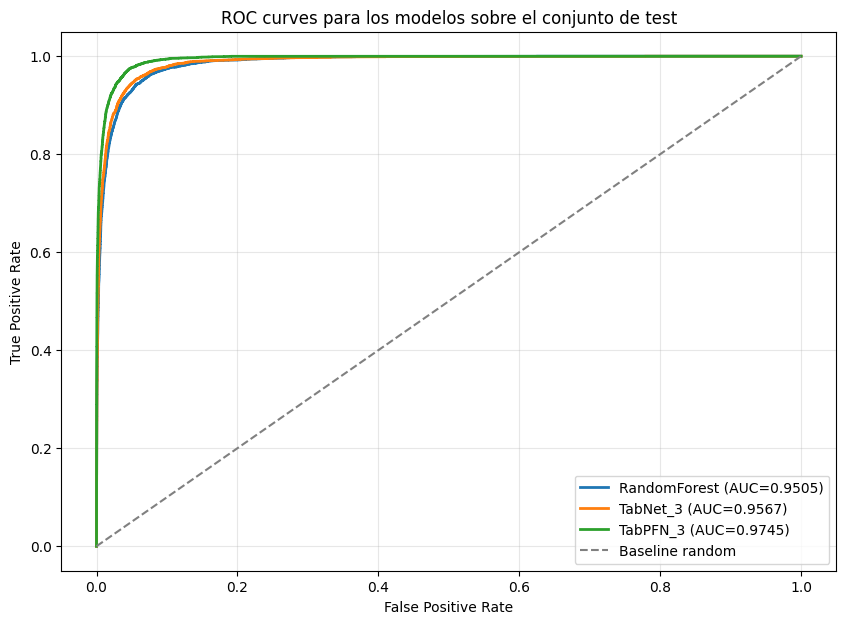


Generando t-SNE sobre features de test...
✓ t-SNE guardado en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\figures\tsne_features_test.png


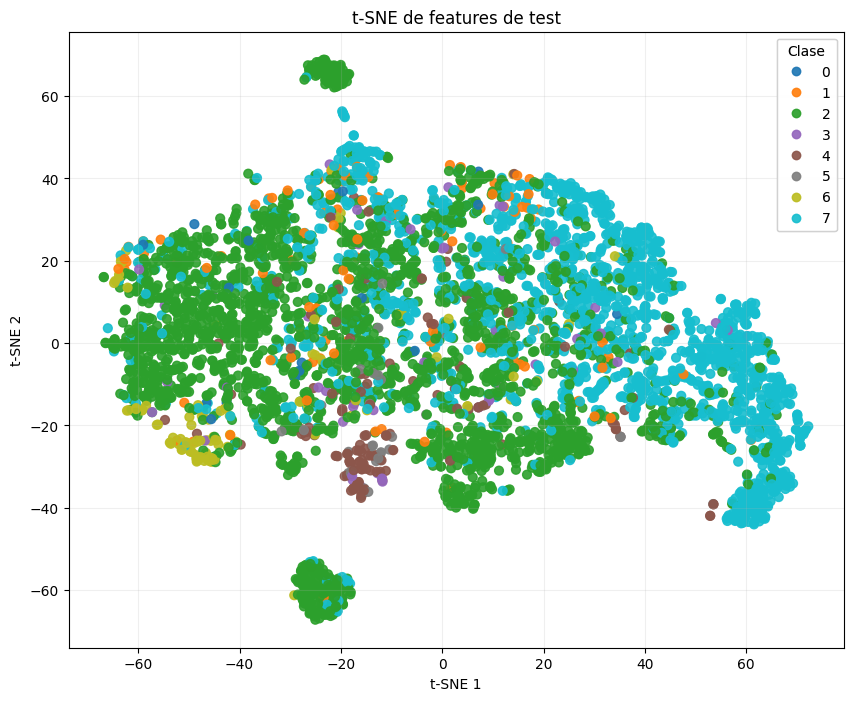


Generando matrices de confusión para cada modelo...

RandomForest:
  ✓ Matriz guardada en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\figures\confusion_matrix_randomforest.png


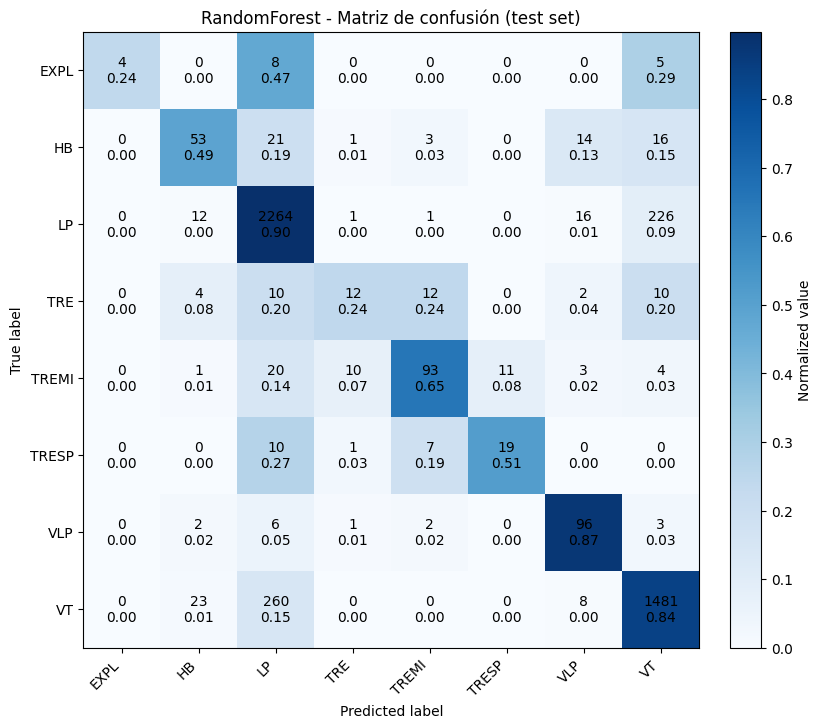


TabNet_3:
  ✓ Matriz guardada en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\figures\confusion_matrix_tabnet_3.png


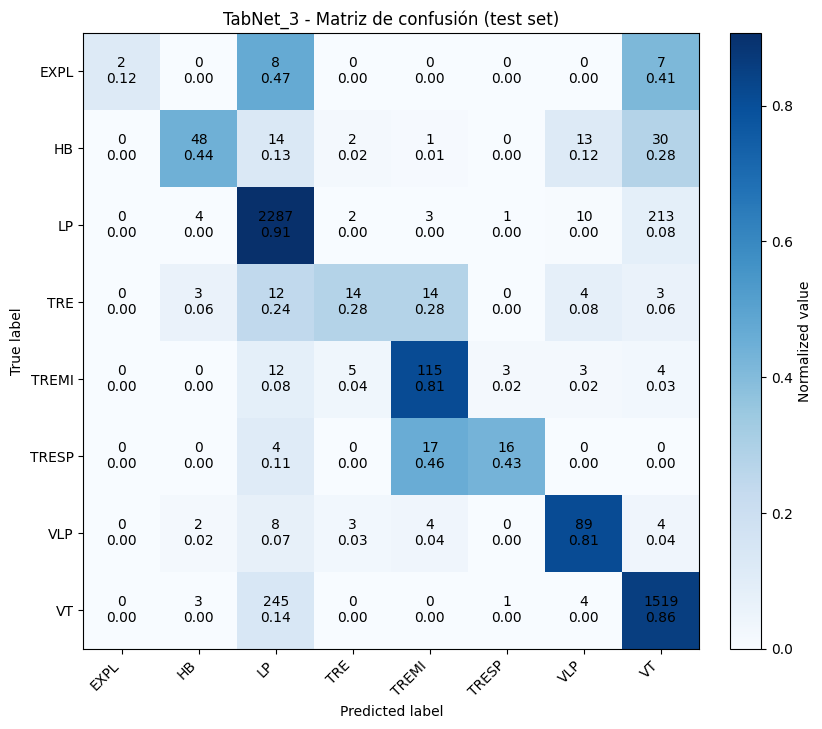


TabPFN_3:
  ✓ Matriz guardada en: c:\Users\ricar\OneDrive\Desktop\TESIS\results\20260531T231213Z\figures\confusion_matrix_tabpfn_3.png


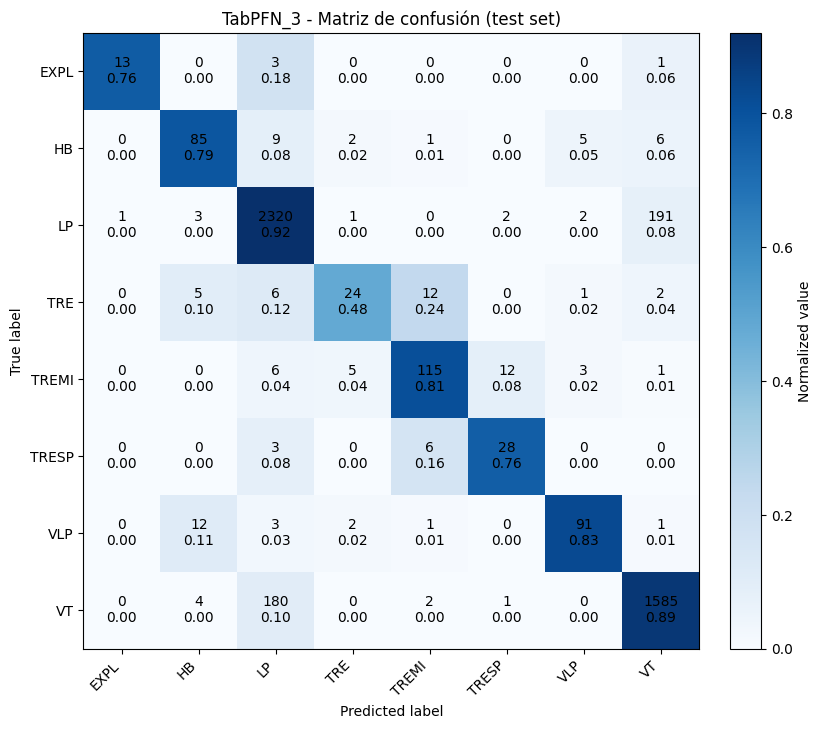


✓ Visualizaciones completadas


In [ ]:
# ============================================================================
# Curvas ROC, AUC, TSNE y Matrices de Confusión sobre Test Set
# ============================================================================

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc

print('\n' + '='*80)
print('ROC, AUC, TSNE y MATRICES DE CONFUSIÓN sobre el conjunto de test')
print('='*80)

classes = le.classes_
n_classes = len(classes)

# Determinar modelos disponibles
model_entries = [
    ('RandomForest', y_pred, y_pred_proba)
]

if 'y_pred_tabnet' in globals() and 'y_pred_proba_tabnet' in globals():
    model_entries.append(('TabNet_3', y_pred_tabnet, y_pred_proba_tabnet))
else:
    print('⚠ TabNet_3 no tiene predicciones disponibles, se omite ROC/confusion. Asegúrate de ejecutar la celda de TabNet primero.')

if 'y_pred_tabpfn' in globals() and 'y_pred_proba_tabpfn' in globals():
    model_entries.append(('TabPFN_3', y_pred_tabpfn, y_pred_proba_tabpfn))
else:
    print('⚠ TabPFN_3 no tiene predicciones disponibles o no está disponible en el entorno, se omite ROC/confusion.')

if len(model_entries) == 1:
    raise RuntimeError('No hay suficientes modelos con predicciones para generar las curvas ROC y las matrices de confusión.')

# ROC curves
print('\nGenerando curvas ROC y calculando AUC...')

if n_classes == 2:
    y_test_bin = y_test
else:
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(10, 7))
for name, y_pred_model, y_proba_model in model_entries:
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test, y_proba_model[:, 1])
        auc_score = auc(fpr, tpr)
    else:
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba_model.ravel())
        auc_score = roc_auc_score(y_test_bin, y_proba_model, average='weighted', multi_class='ovr')

    print(f'  {name}: AUC = {auc_score:.6f}')
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Baseline random')
ax.set_title('ROC curves para los modelos sobre el conjunto de test')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim(0.0, 0.2)
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
roc_path = os.path.join(results_figures_dir, 'roc_curves_test.png')
fig.savefig(roc_path, dpi=200, bbox_inches='tight')
print(f'✓ Curvas ROC guardadas en: {roc_path}')
plt.show()

# TSNE sobre features de test
print('\nGenerando t-SNE sobre features de test...')

X_test_scaled = StandardScaler().fit_transform(X_test)
X_tsne = TSNE(n_components=2, random_state=random_state, init='pca', learning_rate='auto', perplexity=30)
X_test_tsne = X_tsne.fit_transform(X_test_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='tab10', s=40, alpha=0.9)
handles, _ = scatter.legend_elements()
ax.legend(handles, classes, title='Clase', loc='best')
ax.set_title('t-SNE de features de test')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(alpha=0.2)
tsne_path = os.path.join(results_figures_dir, 'tsne_features_test.png')
fig.savefig(tsne_path, dpi=200, bbox_inches='tight')
print(f'✓ t-SNE guardado en: {tsne_path}')
plt.show()

# Matrices de confusión con conteo y normalizado
print('\nGenerando matrices de confusión para cada modelo...')
for name, y_pred_model, y_proba_model in model_entries:
    print(f'\n{name}:')
    cm = confusion_matrix(y_test, y_pred_model)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{name} - Matriz de confusión (test set)')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(classes)

    for i in range(n_classes):
        for j in range(n_classes):
            count = cm[i, j]
            norm_value = cm_norm[i, j]
            text = f'{count}\n{norm_value:.2f}'
            ax.text(j, i, text, ha='center', va='center', color='black', fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Normalized value')
    cm_path = os.path.join(results_figures_dir, f'confusion_matrix_{name.lower()}.png')
    fig.savefig(cm_path, dpi=200, bbox_inches='tight')
    print(f'  ✓ Matriz guardada en: {cm_path}')
    plt.show()

print('\n' + '='*80)
print('✓ Visualizaciones completadas')
print('='*80)
